In [33]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import mpltern
from ipywidgets import interact, FloatSlider, Dropdown
from nrtl_ternary import NRTLTernary
from nrtl_ternary import NRTLTernary, build_tau


In [36]:
model = NRTLTernary.from_csv('data/nrtl-data.csv')
model.summary()

ALPHA = model.alpha
pairs = [(0,1),(0,2),(1,0),(1,2),(2,0),(2,1)]
TAU_BASE = np.zeros((3, 3))
TAU_T    = np.zeros((3, 3))
for k, (i, j) in enumerate(pairs):
    TAU_BASE[i, j] = model.params[k]
    TAU_T[i, j]    = model.params[k + 6]

COMPONENTS = ['water', 'ethanol', 'n-hexane']

def get_gamma(T, x1, x2, x3):
    x = np.array([x1, x2, x3], dtype=float)
    x /= x.sum()
    tau = TAU_BASE + TAU_T / T
    return nrtl(ALPHA, tau, T, x)


Сошлось: True  |  MSE: 3.81e-27  |  итераций: 6554

── tau_base ──
              water   ethanol    hexane
     water   0.0000    2.5828    0.5181
   ethanol  -5.1451    0.0000   -0.0748
    hexane  -6.4826   -6.7639    0.0000

── tau_T (K) ──
              water   ethanol    hexane
     water   0.0000  -519.1800  1953.5091
   ethanol 847.0620    0.0000  2829.7674
    hexane 2281.3970  2039.3428    0.0000


In [37]:
def make_ternary_grid(T, n=60):
    pts = []
    for i in range(n + 1):
        for j in range(n + 1 - i):
            k = n - i - j
            x1, x2, x3 = i / n, j / n, k / n
            if x1 + x2 + x3 > 0:
                pts.append((x1, x2, x3))
    pts = np.array(pts)
    gammas = np.array([get_gamma(T, *p) for p in pts])
    return pts[:, 0], pts[:, 1], pts[:, 2], gammas


In [38]:
def plot_ternary_heatmap(T=298.15, component='γ₁ (water)'):
    comp_map = {'γ₁ (water)': 0, 'γ₂ (ethanol)': 1, 'γ₃ (n-hexane)': 2}
    idx = comp_map[component]

    x1, x2, x3, gammas = make_ternary_grid(T, n=60)
    values = gammas[:, idx]

    fig, ax = plt.subplots(
        figsize=(6, 5),
        subplot_kw=dict(projection='ternary')
    )

    cs = ax.tripcolor(x1, x2, x3, values, cmap='RdYlBu_r', shading='gouraud')
    cbar = fig.colorbar(cs, ax=ax, pad=0.1)
    cbar.set_label(component, fontsize=11)

    ax.set_tlabel(COMPONENTS[0], fontsize=11)
    ax.set_llabel(COMPONENTS[1], fontsize=11)
    ax.set_rlabel(COMPONENTS[2], fontsize=11)
    ax.taxis.set_label_position('tick1')
    ax.laxis.set_label_position('tick1')
    ax.raxis.set_label_position('tick1')

    ax.set_title(f'{component}  |  T = {T:.1f} K', pad=12)
    plt.tight_layout()
    plt.show()


In [39]:
interact(
    plot_ternary_heatmap,
    T=FloatSlider(value=298.15, min=280, max=370, step=5,
                  description='T (K)', continuous_update=False),
    component=Dropdown(
        options=['γ₁ (water)', 'γ₂ (ethanol)', 'γ₃ (n-hexane)'],
        value='γ₁ (water)',
        description='Component'
    )
);


interactive(children=(FloatSlider(value=298.15, continuous_update=False, description='T (K)', max=370.0, min=2…

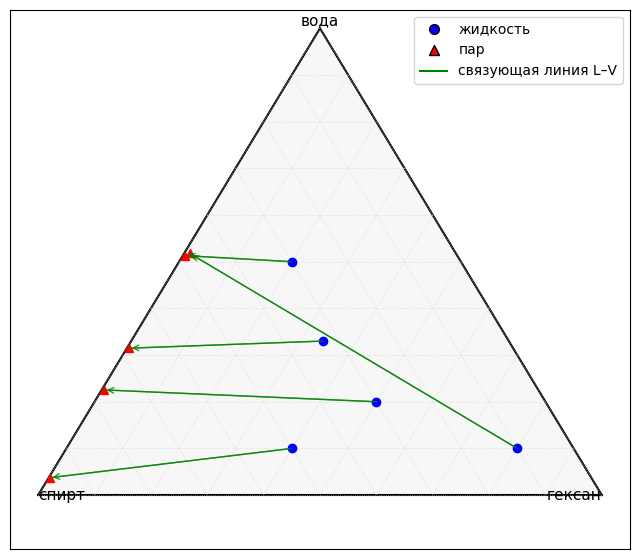

In [ ]:
import ternary
from ternary.helpers import project_point
from matplotlib.lines import Line2D
from nrtl import bubbleP_nrtl

liquid_points = [
    (0.2, 0.3, 0.5),
    (0.5, 0.3, 0.2),
    (0.1, 0.5, 0.4),
    (0.33, 0.33, 0.34),
    (0.1, 0.1, 0.8),
]

T = 298.15
Psat = get_Psat(T)
tau  = build_tau(model.params, T)

fig, tax = ternary.figure(scale=1.0)
fig.set_size_inches(8, 7)
tax.boundary()
tax.gridlines(multiple=0.1, color="lightgray", linewidth=0.5, ls=":")
tax.annotate("гексан", (1, 0, 0), ha="right",  va="center", fontsize=11)
tax.annotate("вода",   (0, 1, 0), ha="center", va="bottom", fontsize=11)
tax.annotate("спирт",  (0, 0, 1), ha="left",   va="center", fontsize=11)

ax = tax.get_axes()

def draw_arrow(p_from, p_to, **kwargs):
    x0, y0 = project_point(p_from)
    x1, y1 = project_point(p_to)
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", **kwargs))

for x1, x2, x3 in liquid_points:
    x = np.array([x1, x2, x3])
    P_guess = np.sum(x * Psat)
    P_bub, xv = bubbleP_nrtl(P_guess, x.copy(), Psat, model.alpha, tau, T, x)

    pL = (x3,  x1,  x2)   # (гексан, вода, спирт)
    pV = (xv[2], xv[0], xv[1])

    tax.plot([pL], marker="o", color="blue",  markersize=6)
    tax.plot([pV], marker="^", color="red",   markersize=6)
    tax.line(pL, pV, linewidth=1, color="green", alpha=0.7, marker=None)
    draw_arrow(pL, pV, color="green", linewidth=1, alpha=0.8)

legend_elements = [
    Line2D([0],[0], marker="o", color="none", markerfacecolor="blue",  markersize=7, label="жидкость"),
    Line2D([0],[0], marker="^", color="none", markerfacecolor="red",   markersize=7, label="пар"),
    Line2D([0],[0], color="green", lw=1.5, label="связующая линия L–V"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)
tax.clear_matplotlib_ticks()
plt.show()